# Gradient Descent Update Rules

## Quick, easy revision notes
Gradient Descent is a way to improve a prediction line step by step. It keeps changing the line until its errors become small. Imagine walking downhill until you reach the lowest point of a bowl.

## What are we changing?
The prediction line is:

$$ŷ = θ_0 + θ_1x$$

- $θ_0$ is the starting height. It moves the line up or down.
- $θ_1$ controls the tilt of the line.

We change both values to make the predictions closer to the real values. This makes the cost smaller.

## The general update idea
Repeat these steps until the cost does not become much smaller:

$$θ_j := θ_j - α\frac{∂J(θ)}{∂θ_j}$$

The `:=` symbol means “replace the old value with the new value.” The derivative $\frac{∂J}{∂θ_j}$ is just the **uphill/downhill clue**: it tells us which way the cost bowl slopes for this parameter.

- Negative derivative: subtracting a negative number makes $θ_j$ increase.
- Positive derivative: subtracting a positive number makes $θ_j$ decrease.
- Near the bottom, the derivative is almost 0, so the changes become very small.

## Learning rate ($α$)
$α$ controls how big each step is.

| Learning rate | What happens? |
|---|---|
| Too small | Moves safely, but takes a long time |
| Good size | Moves toward the lowest cost smoothly |
| Too large | May jump over the best point and keep missing it |

A small value such as $0.001$ or $0.01$ is often used to start. The best value depends on the data.

## Update rules for Simple Linear Regression
Let $m$ be the number of data points and $error = ŷ - y$. Then:

$$θ_0 := θ_0 - α × (1 / m) ∑_{i=1}^{m} (ŷ^{(i)} - y^{(i)})$$

$$θ_1 := θ_1 - α × (1 / m) ∑_{i=1}^{m} (ŷ^{(i)} - y^{(i)})x^{(i)}$$

You do not need to memorise the whole formula at first. The main idea is simple: use the errors to decide how to change the starting height and the tilt of the line.

**Important:** calculate both new values using the old values, and then change them together.

### Why do the two update rules look different?

Think of the line as a ruler:

- $θ_0$ lifts the whole ruler up or down. Every prediction moves by the same amount, so its update uses the **average error**.
- $θ_1$ tilts the ruler. A point with a larger $x$ value moves more when we tilt it, so its update uses **error × x**.

That is the only big difference to remember:

$$θ_0: \text{error} \qquad θ_1: \text{error} \times x$$

You do not need to do the calculus by hand at first. The formulas are the machine's instructions for fixing the line's height and tilt.

### What happens in one full step?

The $\sum$ sign means “look at **all $m$ training points** and add their clues.” One full update does this:

1. Use the current $θ_0$ and $θ_1$ to predict every training point.
2. Find every error: prediction minus actual value.
3. Calculate both changes from those same old values.
4. Update $θ_0$ and $θ_1$ **together**.

Using all training points for one update is called **batch gradient descent**. Updating one parameter first and using its new value while calculating the other would be unfair, so we calculate both changes before replacing either value.

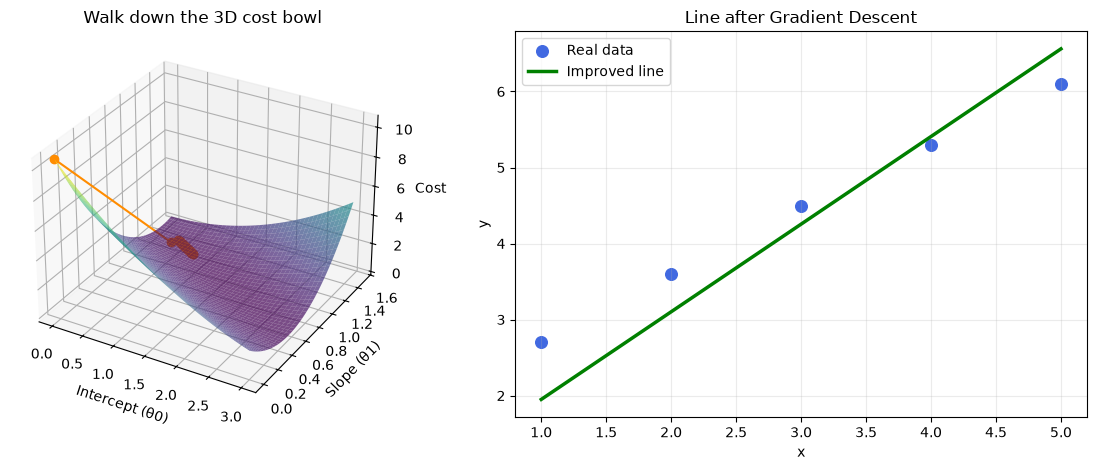

Final intercept (theta0): 0.80
Final slope (theta1): 1.15


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Small dataset: the real pattern is close to y = 2 + 0.8x
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2.7, 3.6, 4.5, 5.3, 6.1])

theta0 = 0.0  # starting intercept
theta1 = 0.0  # starting slope
alpha = 0.08
steps = 25
path_theta0 = []
path_theta1 = []
path_cost = []

for _ in range(steps):
    prediction = theta0 + theta1 * x
    error = prediction - y
    path_theta0.append(theta0)
    path_theta1.append(theta1)
    path_cost.append(np.mean(error ** 2) / 2)

    # Find both changes from the current line, then update together
    change_theta0 = np.mean(error)
    change_theta1 = np.mean(error * x)
    theta0 = theta0 - alpha * change_theta0
    theta1 = theta1 - alpha * change_theta1

# Make a 3D cost bowl because both intercept and slope are changing
theta0_grid, theta1_grid = np.meshgrid(np.linspace(0, 3, 45), np.linspace(0, 1.5, 45))
surface_cost = np.mean((theta0_grid[..., None] + theta1_grid[..., None] * x - y) ** 2, axis=2) / 2

fig = plt.figure(figsize=(12, 4.8))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(theta0_grid, theta1_grid, surface_cost, cmap='viridis', alpha=0.7)
ax1.plot(path_theta0, path_theta1, path_cost, 'o-', color='darkorange', label='Gradient Descent steps')
ax1.set_xlabel('Intercept (θ0)')
ax1.set_ylabel('Slope (θ1)')
ax1.set_zlabel('Cost')
ax1.set_title('Walk down the 3D cost bowl')

ax2 = fig.add_subplot(122)
ax2.scatter(x, y, color='royalblue', s=70, label='Real data')
ax2.plot(x, theta0 + theta1 * x, color='green', linewidth=2.5, label='Improved line')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Line after Gradient Descent')
ax2.grid(alpha=0.25)
ax2.legend()
plt.tight_layout()
plt.show()

print(f'Final intercept (theta0): {theta0:.2f}')
print(f'Final slope (theta1): {theta1:.2f}')

### What the diagram and code mean
- Left graph: orange dots show the model taking small steps down the cost bowl.
- Right graph: the green line is the improved prediction line.
- The code starts with a poor line, finds its errors, and changes $θ_0$ and $θ_1$ repeatedly.

The cost curve is like a bowl. **Gradient Descent** is the process of walking down to the bottom.

## Two-parameter picture
A model has two values to learn: $θ_0$ and $θ_1$. For every pair of values, we can calculate one cost (how wrong the line is).

If we draw $θ_0$ and $θ_1$ on the floor and the cost as height, the result looks like a 3D bowl. A high place means more error; a low place means less error.

Gradient Descent starts with any pair of values, then takes small steps toward lower cost. It keeps doing this until it reaches the lowest part of the bowl. That lowest point is the **global minimum**, where the model has the smallest error and usually the best-fit line.

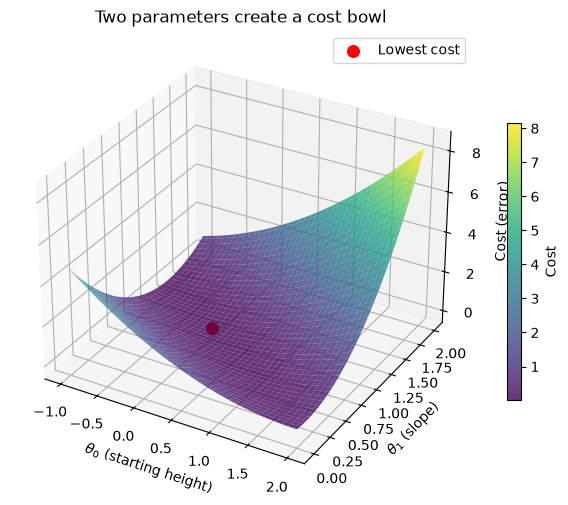

Lowest cost: 0.000
Best theta_0: 0.03
Best theta_1: 0.99


In [3]:
# Visualize how theta_0 and theta_1 create a 3D cost bowl
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.0, 2.0, 3.0])
y = np.array([1.0, 2.0, 3.0])

def cost(theta_0, theta_1):
    predictions = theta_0 + theta_1 * x
    return np.mean((predictions - y) ** 2, axis=-1) / 2

theta_0_values = np.linspace(-1, 2, 80)
theta_1_values = np.linspace(0, 2, 80)
theta_0_grid, theta_1_grid = np.meshgrid(theta_0_values, theta_1_values)
cost_grid = cost(theta_0_grid[..., None], theta_1_grid[..., None])

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(
    theta_0_grid, theta_1_grid, cost_grid,
    cmap='viridis', alpha=0.8, edgecolor='none'
)

best_index = np.unravel_index(np.argmin(cost_grid), cost_grid.shape)
best_theta_0 = theta_0_grid[best_index]
best_theta_1 = theta_1_grid[best_index]
best_cost = cost_grid[best_index]
ax.scatter(best_theta_0, best_theta_1, best_cost, color='red', s=70, label='Lowest cost')

ax.set_xlabel(r'$\theta_0$ (starting height)')
ax.set_ylabel(r'$\theta_1$ (slope)')
ax.set_zlabel('Cost (error)')
ax.set_title('Two parameters create a cost bowl')
ax.legend()
fig.colorbar(surface, ax=ax, shrink=0.6, label='Cost')
plt.show()

print(f'Lowest cost: {best_cost:.3f}')
print(f'Best theta_0: {best_theta_0:.2f}')
print(f'Best theta_1: {best_theta_1:.2f}')

## Things to remember
- $θ_0$ moves the line up or down, while $θ_1$ changes its tilt.
- The cost tells us how wrong the line is. Smaller cost means a better line.
- Every pair of $θ_0$ and $θ_1$ gives one point on the 3D cost bowl.
- High places on the bowl mean large errors; low places mean small errors.
- Gradient Descent always tries to move downhill, toward a smaller cost.
- The learning rate $α$ controls the step size. Too small is slow; too large can jump over the best point.
- When the slope is close to zero, the model is near the bottom and the updates become small.
- The lowest point is the **global minimum**: the place with the smallest cost for the model.
- Calculate the new $θ_0$ and $θ_1$ from the old values, then update them together.
- Feature scaling can help Gradient Descent reach the minimum faster and more smoothly.

**Memory trick:** `calculate cost → find the downhill direction → take a small step → repeat.`

## One-minute revision
- Gradient Descent improves the line one step at a time.
- A derivative tells us which way the cost curve is sloping.
- A negative slope makes a parameter increase; a positive slope makes it decrease.
- $α$ controls the size of each step.
- The global minimum is the lowest cost and usually gives the best line.
- Change $θ_0$ and $θ_1$ together using their old values.

**Memory trick:** `look at the slope → step downhill → repeat → reach the bottom.`